In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set premium aesthetics
sns.set_style('whitegrid')
py.rcParams['figure.figsize']=(10, 6)
            
# Load the car dataset
df = pd.read_csv('cars_data.csv')
print(df.head())


          Car       Model  Volume  Weight  CO2
0      Toyota        Aygo    1000     790   99
1  Mitsubishi  Space Star    1200    1160   95
2       Skoda      Citigo    1000     929   95
3        Fiat         500     900     865   90
4        Mini      Cooper    1500    1140  105


In [3]:
# Independent variable(X)
X=df[['Weight','Volume']]

# Dependent variable(y)
y=df['CO2']

In [4]:
# Initialize and train the multiple regression model
model = LinearRegression()
model.fit(X, y)

print("Multiple Regression model trained successfully.")


Multiple Regression model trained successfully.


In [5]:
# Output the coefficients and intercept
print(f"Coefficients(Weight, Volume): {model.coef_}")
print(f"Intercept:{model.intercept_:.4f}")


Coefficients(Weight, Volume): [-0.00717634  0.00826465]
Intercept:94.9395


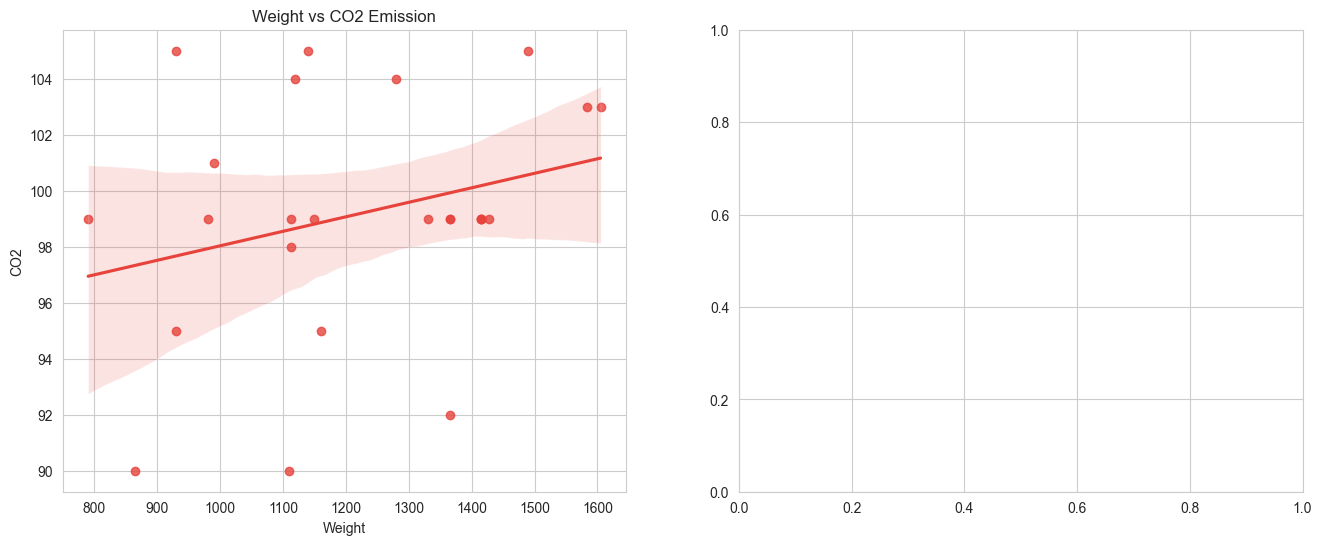

In [6]:
# Visualize relationships
fig,(ax1,ax2)=py.subplots(1,2,figsize=(16,6))
sns.regplot(x='Weight', y='CO2',data=df,ax=ax1,color='#e7433c')
ax1.set_title('Weight vs CO2 Emission')
py.show()

In [7]:
# Custom prediction function with user input
def predict_co2(weight, volume):
    prediction = model.predict([[weight, volume]])[0]
    print(f"\n Predicted CO2 Emission: ")
    print(f"Volume:{volume}ccm")
    print(f"Weight:{weight}kg,Volime:{volume}ccm")
    print(f"Estimated CO2 Emission: {prediction:.2f} g/km")

    # Get input from user
    try:
        u_weight=float(input("Enter the weight of the car (in kg): "))
        u_volume=float(input("Enter the engine volume (in ccm): "))
        predict_co2(u_weight, u_volume)
    except ValueError:
        print("Please enter numeric values.")
        

In [8]:
# Model Evaluation
y_pred = model.predict(X)
accuracy = r2_score(y, y_pred)
print(f"Model R² Score: {accuracy:.4f}")
print("(Note: R² indicates how well the independent variables explain the variance of CO2)")

Model R² Score: 0.2012
(Note: R² indicates how well the independent variables explain the variance of CO2)
